In [1]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from scipy.optimize import differential_evolution
from sklearn.linear_model import LinearRegression

In [2]:
# ----------------------------------------------------
# 1. 앙상블 모델 및 스케일러 로딩
# ----------------------------------------------------
N_ENSEMBLE = 10
TARGET_NAMES = ["Deflection(mm)", "Weight(kg)"]
MODEL_PATHS = [f'saved_models/pv_ensemble_model_{i+1}.keras' for i in range(N_ENSEMBLE)]
SCALER_DIR = '.' # 스케일러 디렉토리 경로
OUTPUT_DIR = 'robustness_analysis_DE_PV'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("--- 앙상블 모델 및 스케일러 로딩 시작 ---")
try:
    ENSEMBLE_MODELS = [load_model(path, compile=False) for path in MODEL_PATHS]
except Exception as e:
    print(f"오류: 앙상블 모델 로드 실패. ({e})")
    ENSEMBLE_MODELS = [] 

try:
    X_SCALER_LOADED = joblib.load(os.path.join(SCALER_DIR, 'scaler_X_pvmodule.joblib')) 
    Y_SCALER_LOADED = joblib.load(os.path.join(SCALER_DIR, 'scaler_y_pvmodule.joblib')) 
except Exception as e:
    print(f"오류: 스케일러 로드 실패. ({e})")
    raise
print("앙상블 모델 및 스케일러 로딩 완료.")

--- 앙상블 모델 및 스케일러 로딩 시작 ---
앙상블 모델 및 스케일러 로딩 완료.


C:\Users\admin\anaconda3\envs\py31010_auto\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
# ----------------------------------------------------
# 2. 제약 조건 및 탐색 설정
# ----------------------------------------------------
CONSTRAINTS = {
    "Deflection(mm)": {"min": None, "max": 12.3}, 
    "Weight(kg)": {"min": None, "max": 3.6}        
}
PENALTY_CONST = 100.0

INPUT_BOUNDS = [(1.5, 2.5), (8.0, 14.0), (1.5, 2.5), (1.7, 3.0), (2.5, 5.0)]

TOLERANCES_TO_ANALYZE = [0.05, 0.10, 0.20, 0.50]
N_RUNS = 50
BASE_WEIGHT = 1.0

In [4]:
# ----------------------------------------------------
# 3. 동적 가중치 반영 DE 목적 함수 Wrapper
# ----------------------------------------------------
def create_de_objective_constrained_robustness(current_weights):
    def wrapper_objective(X):
        a, b, c, d, e = X 
        
        X_input = np.array([[a, b, c, d, e]])
        X_scaled = X_SCALER_LOADED.transform(X_input)
        
        # 앙상블 평균 예측 (원본 물리적 값)
        if not ENSEMBLE_MODELS: return 100 # 모델 없으면 강제 페널티
        preds_raw = [model.predict(X_scaled, verbose=0)[0] for model in ENSEMBLE_MODELS]
        y_pred_mean_raw = np.mean(np.array(preds_raw), axis=0)

        # 공평한 F_obj 계산을 위한 스케일링
        y_pred_mean_scaled = Y_SCALER_LOADED.transform(y_pred_mean_raw.reshape(1, -1))[0]

        # 변위(음수)는 최대화(+1), 무게(양수)는 최소화(-1)
        GOAL_SIGNS = np.array([1, -1]) 
        F_obj_unpenalized = np.sum(GOAL_SIGNS * current_weights * y_pred_mean_scaled)
        
        # 제약 조건 검사 및 벌칙 적용
        penalty = 0.0
        for i, target_name in enumerate(TARGET_NAMES):
            value = y_pred_mean_raw[i]
            check_value = abs(value) if target_name == "Deflection(mm)" else value
                    
            if target_name in CONSTRAINTS:
                max_req = CONSTRAINTS[target_name]["max"]
                if max_req is not None and check_value > max_req:
                    penalty += PENALTY_CONST * (check_value - max_req)
        
        F_obj_constrained = F_obj_unpenalized - penalty
        
        # scipy DE는 최소화를 수행하므로 부호 반전하여 반환
        return -F_obj_constrained 
        
    return wrapper_objective

# ----------------------------------------------------
# 4. DE 가중치 민감도 분석 실행 로직
# ----------------------------------------------------
print("\n" + "="*50)
print("  🚀 PV 모듈 DE 가중치 민감도 분석 시작")
print("="*50)
start_total = time.time()

all_analysis_results = []

for tolerance in TOLERANCES_TO_ANALYZE:
    print(f"\n[시나리오] 가중치 변동 허용 오차: ±{int(tolerance*100)}% (총 {N_RUNS}회 반복)")
    
    runs_data = []
    for run_id in range(N_RUNS):
        # 1. 가중치 2개 무작위 샘플링
        w1 = np.random.uniform(BASE_WEIGHT * (1 - tolerance), BASE_WEIGHT * (1 + tolerance))
        w2 = np.random.uniform(BASE_WEIGHT * (1 - tolerance), BASE_WEIGHT * (1 + tolerance))
        current_weights = np.array([w1, w2])

        # 2. 현재 가중치가 반영된 DE 목적 함수 생성
        de_objective = create_de_objective_constrained_robustness(current_weights)

        # 3. DE 알고리즘 실행 (Max Iter: 40, Pop Size: 10)
        result = differential_evolution(
            func=de_objective, 
            bounds=INPUT_BOUNDS,
            strategy='best1bin',
            maxiter=40,
            popsize=10,
            seed=run_id # 재현성을 위한 시드 고정
        )

        # 4. 결과 추출 (최대화 값으로 다시 부호 반전)
        best_x = result.x
        best_f_obj = -result.fun
        
        run_record = {
            'Run': run_id + 1,
            'Tolerance': tolerance,
            'Best_F_obj': best_f_obj,
            'W_1': w1, 'W_2': w2,
            'a': best_x[0], 'b': best_x[1], 'c': best_x[2], 'd': best_x[3], 'e': best_x[4]
        }
        runs_data.append(run_record)
        
        if (run_id + 1) % 10 == 0:
            print(f"  Run {run_id+1}/{N_RUNS} 완료...")
            
    # 시나리오 결과 병합 및 저장
    df_result = pd.DataFrame(runs_data)
    all_analysis_results.append(df_result)
    
    tolerance_percent = int(tolerance * 100)
    file_name = os.path.join(OUTPUT_DIR, f'de_robustness_results_{tolerance_percent}pct_pv.csv') 
    df_result.to_csv(file_name, index=False)

print(f"\n--- 전체 DE 민감도 분석 완료 ({time.time() - start_total:.2f}초) ---")


  🚀 PV 모듈 DE 가중치 민감도 분석 시작

[시나리오] 가중치 변동 허용 오차: ±5% (총 50회 반복)
  Run 10/50 완료...
  Run 20/50 완료...
  Run 30/50 완료...
  Run 40/50 완료...
  Run 50/50 완료...

[시나리오] 가중치 변동 허용 오차: ±10% (총 50회 반복)
  Run 10/50 완료...
  Run 20/50 완료...
  Run 30/50 완료...
  Run 40/50 완료...
  Run 50/50 완료...

[시나리오] 가중치 변동 허용 오차: ±20% (총 50회 반복)
  Run 10/50 완료...
  Run 20/50 완료...
  Run 30/50 완료...
  Run 40/50 완료...
  Run 50/50 완료...

[시나리오] 가중치 변동 허용 오차: ±50% (총 50회 반복)
  Run 10/50 완료...
  Run 20/50 완료...
  Run 30/50 완료...
  Run 40/50 완료...
  Run 50/50 완료...

--- 전체 DE 민감도 분석 완료 (363255.44초) ---



=== 최종 DE 강건성 비교 요약 (PV 프레임 제약 조건 반영) ===
-----------------------------------------------------------------------------------------
  Tolerance | F_obj Mean | F_obj Std | F_obj CV (%) | X_best Avg CV (%) (a, b, c, d, e)
-----------------------------------------------------------------------------------------
  ±05%      |   0.6659  |   0.0160 |    2.41%       |    0.46%
  ±10%      |   0.6667  |   0.0398 |    5.97%       |    0.57%
  ±20%      |   0.6935  |   0.0754 |   10.87%       |    2.84%
  ±50%      |   0.6488  |   0.2137 |   32.94%       |    5.93%
-----------------------------------------------------------------------------------------

    🔍 DE 입력 변수별 가중치 민감도 상세 분석 (Regression)


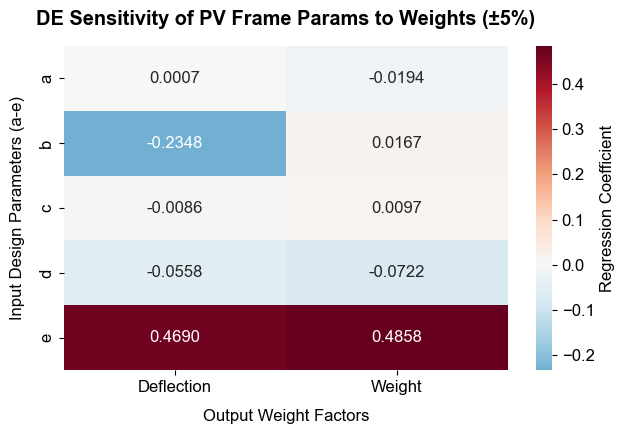

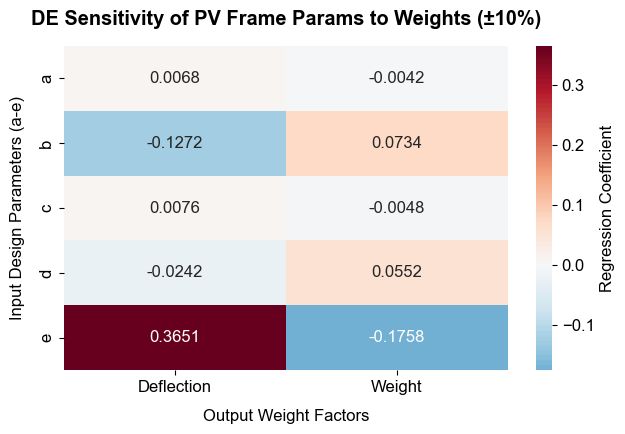

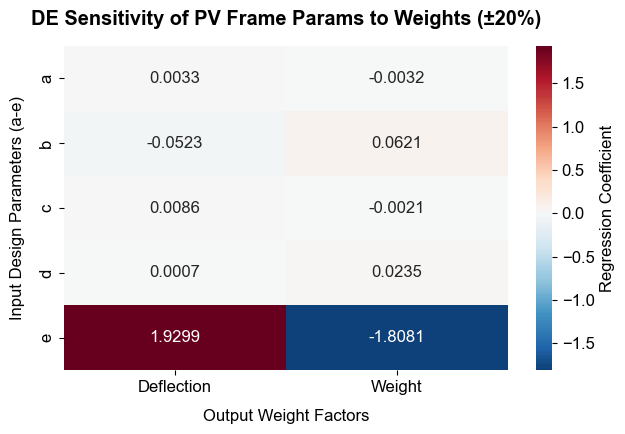

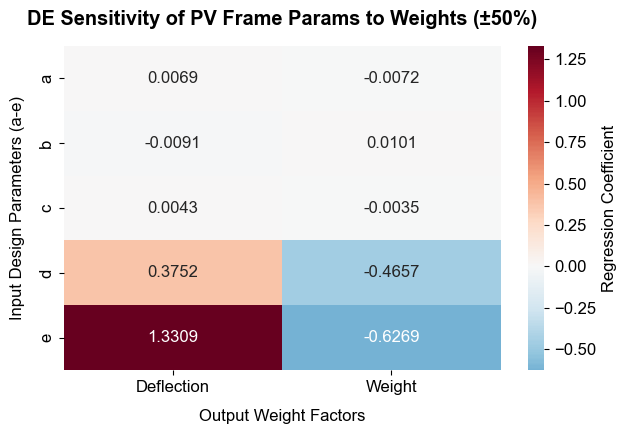


✅ 모든 분석 및 이미지 저장이 완료되었습니다.


In [5]:
# ----------------------------------------------------
# 5. 최종 결과 요약 및 비교 분석
# ----------------------------------------------------
X_cols = ['a', 'b', 'c', 'd', 'e']
print("\n=== 최종 DE 강건성 비교 요약 (PV 프레임 제약 조건 반영) ===")
print("-----------------------------------------------------------------------------------------")
print("  Tolerance | F_obj Mean | F_obj Std | F_obj CV (%) | X_best Avg CV (%) (a, b, c, d, e)")
print("-----------------------------------------------------------------------------------------")
for df_result in all_analysis_results:
    tolerance = df_result['Tolerance'].iloc[0]
    
    f_obj_mean = df_result['Best_F_obj'].mean()
    f_obj_std = df_result['Best_F_obj'].std()
    f_obj_cv = (f_obj_std / abs(f_obj_mean)) * 100 if f_obj_mean != 0 else 0
    
    x_cvs = []
    for col in X_cols:
        x_mean = df_result[col].mean()
        x_std = df_result[col].std()
        x_cv = (x_std / abs(x_mean)) * 100 if x_mean != 0 else 0
        x_cvs.append(x_cv)
    
    avg_x_cv = np.mean(x_cvs)

    print(f"  ±{int(tolerance*100):02d}%      | {f_obj_mean:8.4f}  | {f_obj_std:8.4f} | {f_obj_cv:7.2f}%       | {avg_x_cv:7.2f}%")
print("-----------------------------------------------------------------------------------------")

# ---------------------------------------------------------------------
# 6. 입력 변수(a, b, c, d, e)별 가중치 민감도 히트맵 시각화
# ---------------------------------------------------------------------
WEIGHT_COLS = ['W_1', 'W_2']
TARGET_NAMES_SHORT = ['Deflection', 'Weight']

print("\n" + "="*65)
print("    🔍 DE 입력 변수별 가중치 민감도 상세 분석 (Regression)")
print("="*65)

for df_res in all_analysis_results:
    tolerance = df_res['Tolerance'].iloc[0]
    tolerance_pct = int(tolerance * 100)
    
    X_weights = df_res[WEIGHT_COLS]
    param_sensitivities = {}
    
    for param in X_cols:
        y_param = df_res[param]
        model_p = LinearRegression()
        model_p.fit(X_weights, y_param)
        param_sensitivities[param] = model_p.coef_
    
    df_sens = pd.DataFrame(param_sensitivities, index=TARGET_NAMES_SHORT).T
    
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12
    
    plt.figure(figsize=(6.5, 4.5))
    sns.heatmap(df_sens, annot=True, cmap='RdBu_r', center=0, fmt='.4f',
                cbar_kws={'label': 'Regression Coefficient'})
    
    plt.title(f'DE Sensitivity of PV Frame Params to Weights (±{tolerance_pct}%)', 
              pad=15, fontweight='bold')
    plt.xlabel('Output Weight Factors', labelpad=10)
    plt.ylabel('Input Design Parameters (a-e)', labelpad=10)
    plt.tight_layout()
    
    save_path = os.path.join(OUTPUT_DIR, f'de_sensitivity_heatmap_{tolerance_pct}pct_pv.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

print("\n✅ 모든 분석 및 이미지 저장이 완료되었습니다.")

[DE] 5% 데이터 시각화 진행 중...


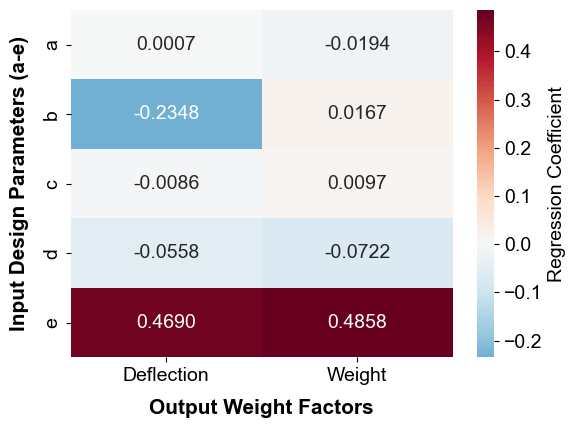

 -> 완료! 저장 위치: Paper_Figures_Heatmap\Fig5_DE_heatmap_5pct_paper.png



In [6]:
# ---------------------------------------------------------------------
# 1. 논문용 글로벌 폰트 및 캔버스 설정
# ---------------------------------------------------------------------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14  # 전체 기본 글자 크기 (축 눈금 등에 적용)

# ---------------------------------------------------------------------
# 2. 분석할 변수 및 타겟 설정
# ---------------------------------------------------------------------
X_PARAMS = ['a', 'b', 'c', 'd', 'e']
WEIGHT_COLS = ['W_1', 'W_2']
TARGET_NAMES_SHORT = ['Deflection', 'Weight']

# 저장된 5% 결과 파일 경로 (실제 파일 경로에 맞게 수정해주세요)
#BO_FILE_PATH = 'robustness_analysis_BO_PV/robustness_results_5pct_pv.csv'
DE_FILE_PATH = 'robustness_analysis_DE_PV/de_robustness_results_5pct_pv.csv'

OUTPUT_DIR = 'Paper_Figures_Heatmap'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------------------------------------------------
# 3. 히트맵 생성 및 저장 함수
# ---------------------------------------------------------------------
def generate_paper_heatmap(file_path, algo_name):
    print(f"[{algo_name}] 5% 데이터 시각화 진행 중...")
    
    # 데이터 로드
    df_res = pd.read_csv(file_path)
    
    X_weights = df_res[WEIGHT_COLS]
    param_sensitivities = {}
    
    # 선형 회귀를 통한 민감도(계수) 추출
    for param in X_PARAMS:
        y_param = df_res[param]
        model_p = LinearRegression()
        model_p.fit(X_weights, y_param)
        param_sensitivities[param] = model_p.coef_
        
    df_sens = pd.DataFrame(param_sensitivities, index=TARGET_NAMES_SHORT).T
    
    # 캔버스 크기 설정 (논문 단단/양단에 맞춰 조절 가능)
    plt.figure(figsize=(6, 4.5))
    
    # 히트맵 그리기
    # annot_kws={"size": 15}를 통해 히트맵 안의 숫자 크기만 따로 조절 가능합니다.
    ax = sns.heatmap(df_sens, annot=True, cmap='RdBu_r', center=0, fmt='.4f',
                     annot_kws={"size": 14}, # 히트맵 내부 숫자 크기
                     cbar_kws={'label': 'Regression Coefficient'})
    
    # 컬러바(Colorbar) 라벨 폰트 크기 조절
    ax.figure.axes[-1].yaxis.label.set_size(14)
    
    # ★ 논문용 시각화 핵심: plt.title() 제거 ★
    # plt.title(...)  <-- 주석 처리 또는 삭제
    
    # X, Y 축 라벨 설정 및 크기 조절
    plt.xlabel('Output Weight Factors', labelpad=10, fontweight='bold', fontsize=15)
    plt.ylabel('Input Design Parameters (a-e)', labelpad=10, fontweight='bold', fontsize=15)
    
    plt.tight_layout()
    
    # 논문 투고용 고해상도(300 DPI) 이미지 저장
    save_path = os.path.join(OUTPUT_DIR, f'Fig5_{algo_name}_heatmap_5pct_paper.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f" -> 완료! 저장 위치: {save_path}\n")

# ---------------------------------------------------------------------
# 4. 함수 실행
# ---------------------------------------------------------------------
#if os.path.exists(BO_FILE_PATH):
#    generate_paper_heatmap(BO_FILE_PATH, "BO")
#else:
#    print(f"오류: BO 파일을 찾을 수 없습니다. 경로를 확인해주세요. ({BO_FILE_PATH})")

if os.path.exists(DE_FILE_PATH):
    generate_paper_heatmap(DE_FILE_PATH, "DE")
else:
    print(f"오류: DE 파일을 찾을 수 없습니다. 경로를 확인해주세요. ({DE_FILE_PATH})")